              party1            party2 currency1 currency2  tenor   notional1  \
0      ATLAS FX6 Ltd        Zomato ltd       INR       UNK      1  12159694.0   
1      ATLAS FX6 Ltd        Zomato ltd       INR       UNK      1  15314690.0   
2      ATLAS FX6 Ltd        Zomato ltd       INR       UNK      1   8574096.0   
3      ATLAS FX6 Ltd        Zomato ltd       INR       UNK      1  16365370.0   
4      ATLAS FX6 Ltd        Zomato ltd       INR       UNK      1  17390609.0   
...              ...               ...       ...       ...    ...         ...   
9995  Global FX4 Ltd  First Street ltd       GBP       UNK      1   4535729.0   
9996  Global FX4 Ltd  First Street ltd       GBP       UNK      1   7004815.0   
9997  Global FX4 Ltd  First Street ltd       GBP       UNK      1   3750476.0   
9998  Global FX4 Ltd  First Street ltd       GBP       UNK      1   6953040.0   
9999  Global FX4 Ltd  First Street ltd       GBP       UNK      1   2263794.0   

      cluster  
0          

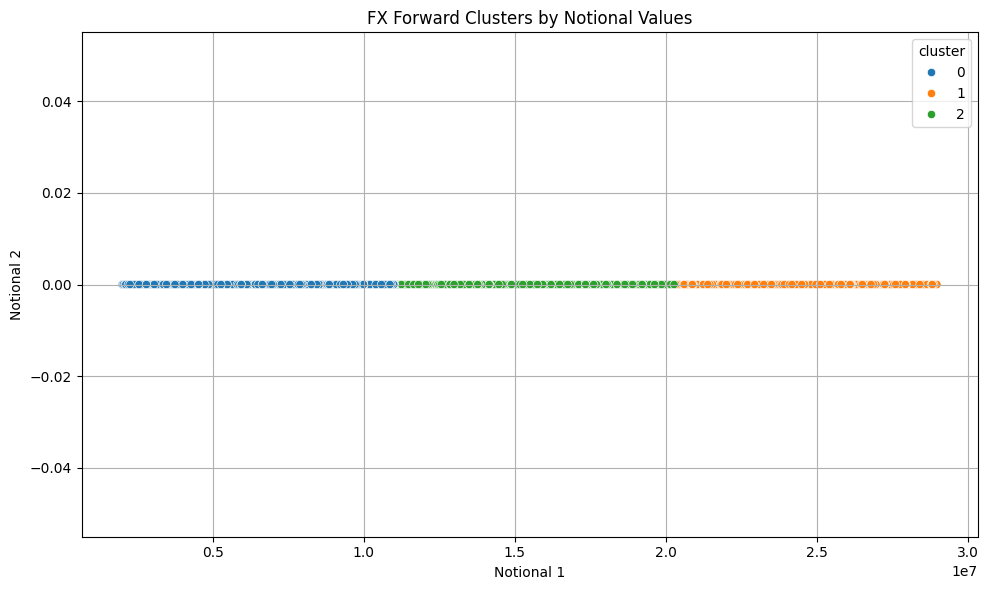

In [3]:
import os
import xml.etree.ElementTree as ET
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# ---------- CONFIG ----------
TRADE_DIR = "./output"  # Change this to your FpML folder path
N_CLUSTERS = 3
# ---------------------------

def parse_fx_forward_trade(file_path):
    ns = {
        'fpml': 'http://www.fpml.org/FpML-5/confirmation'
    }
    try:
        tree = ET.parse(file_path)
        root = tree.getroot()

        trade = root.find(".//fpml:trade", ns)
        party1 = root.find(".//fpml:party[1]", ns)
        party2 = root.find(".//fpml:party[2]", ns)
        if trade is None:
            return None

        trade_date = trade.findtext(".//fpml:tradeDate", default="", namespaces=ns)

        notional1 = trade.findtext(".//fpml:paymentAmount/fpml:amount", default="0", namespaces=ns)
        #notional2 = trade.findtext(".//fpml:receivedAmount/fpml:amount", default="0", namespaces=ns)

        currency1 = trade.find(".//fpml:paymentAmount/fpml:currency", ns)
        currency2 = trade.find(".//fpml:receivedAmount/fpml:currency", ns)

        tenor = trade.findtext(".//fpml:calculationPeriodDates/fpml:tenorPeriod/fpml:periodMultiplier", default="1", namespaces=ns)
        tenor_unit = trade.findtext(".//fpml:calculationPeriodDates/fpml:tenorPeriod/fpml:period", default="M", namespaces=ns)

        party1Id = party1.find(".//fpml:partyId", ns)
        party2Id = party2.find(".//fpml:partyId", ns)

        return {
            "file": os.path.basename(file_path),
            "trade_date": trade_date,
            "notional1": float(notional1),
            #"notional2": float(notional2),
            "currency1": currency1.text if currency1 is not None else "UNK",
            "currency2": currency2.text if currency2 is not None else "UNK",
            "tenor": int(tenor),
            "tenor_unit": tenor_unit,
            "party1": party1Id.text if party1Id is not None else "Party1",
            "party2": party2Id.text if party2Id is not None else "Party2",
        }
    except Exception as e:
        print(f"Failed to parse {file_path}: {e}")
        return None

def load_trades_from_folder(folder):
    data = []
    for fname in os.listdir(folder):
        if fname.endswith(".xml"):
            fpath = os.path.join(folder, fname)
            parsed = parse_fx_forward_trade(fpath)
            if parsed:
                data.append(parsed)
    return pd.DataFrame(data)

def cluster_trades(df, n_clusters=3):
    numeric_features = df[["notional1", "notional2", "tenor"]].copy()
    scaler = StandardScaler()
    scaled = scaler.fit_transform(numeric_features)

    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    df['cluster'] = kmeans.fit_predict(scaled)
    return df, kmeans

def plot_clusters(df):
    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=df, x="notional1", y="notional2", hue="cluster", palette="tab10")
    plt.title("FX Forward Clusters by Notional Values")
    plt.xlabel("Notional 1")
    plt.ylabel("Notional 2")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# --- MAIN ---
if __name__ == "__main__":
    df = load_trades_from_folder(TRADE_DIR)
    if df.empty:
        print("No trades loaded. Please check the TRADE_DIR path and contents.")
    else:
        clustered_df, model = cluster_trades(df, N_CLUSTERS)
        print(clustered_df[["party1", "party2", "currency1", "currency2", "tenor", "notional1", "cluster"]].head(10000))
        plot_clusters(clustered_df)
